In [1]:
import time

##
Physics Engine
##

###
Python is a versatile programming language. It is the primary tool for working with data and has beaten in popularity other similar data visualisation and data transformation languages such as R. The simplicity of Python allows for sufficient proficiency in it to be obtained in relatively short time. 

There have been many iterations of physics simulating engines in different languages. In C and C++ there is a greater freedom working with processing memory and therefore allows for better performance if their tools are properly utilized.
###

### [Newton defined a vector quantity called linear momentum ***p*** which is the product of mass and velocity](https://phys.libretexts.org/Bookshelves/Classical_Mechanics/Variational_Principles_in_Classical_Mechanics_(Cline)/02:_Review_of_Newtonian_Mechanics/2.02:_Newton's_Laws_of_motion).

$$p = mr$$

Since the mass ***m*** is a scalar quantity, then the velocity vector ***r*** and the linear momentum vector ***p*** are colinear.
Newton’s laws, expressed in terms of linear momentum, are:

 1.Law of inertia: A body remains at rest or in uniform motion unless acted upon by a force. 
$$ F = \frac{dp}{dt}$$

 2.Equation of motion: A body acted upon by a force moves in such a manner that the time rate of change of momentum equals the force. 

 3.Action and reaction: If two bodies exert forces on each other these forces are equal in magnitude and opposite in direction. 




In a 1D environment,the space to work with is line, if we have an object at any point we can simulate movement by having a particle decelerate slightly in order to show "drag", in actuality it serves simply to present a change in velocity.

There are many different ways in which a particle in such a simulation. A wall can be added that reverses the velocity of the particle, utilizing Newton's second law. If we do not have any additional variables we can assume that throught preservation of momentum, [the particle we have will preserve it's velocity](https://physics.stackexchange.com/questions/706071/ball-collision-with-a-wall) with a negative speed.

In [4]:


class Particle1D:
    def __init__(self, position=0.0, velocity=40.0):
        self.x = position
        self.v = velocity

    def update(self, dt, drag=0.15):
        self.v *= (1 - drag * dt)
        
        self.x += self.v * dt

    def __str__(self):
        return f"x = {self.x:8.2f} m    v = {self.v:8.2f} m/s"

p = Particle1D(position=-19.0, velocity=50.0)


t = 0.0
dt = 0.08
total_time = 5.0

def make_position_bar(x, scale=1.0, width=50):
    """ Crude ASCII bar showing position """
    center = width // 2
    wall_left = center-20 / scale
    wall_right = center + 20 / scale

    pos = int(round(x * scale)) + center

    

    
    bar = ["-"] * width
    bar[center] = "|"
    bar[pos] = "●"
    bar[int(round(wall_left))] = "L"
    bar[int(round(wall_right))] = "R"

    return "".join(bar)


while t < total_time:

    p.update(dt=dt, drag=0.1)
    if p.x+(p.v*dt)>=20 or p.x+(p.v*dt)<=-20:
        p.v=-p.v
        
    bar = make_position_bar(p.x)
    print(f"t = {t:5.2f}s   {bar}   {p}")
        
    time.sleep(dt * 0.8)
    t += dt





t =  0.00s   -----L----●--------------|-------------------R----   x =   -15.03 m    v =    49.60 m/s
t =  0.08s   -----L--------●----------|-------------------R----   x =   -11.10 m    v =    49.20 m/s
t =  0.16s   -----L------------●------|-------------------R----   x =    -7.19 m    v =    48.81 m/s
t =  0.24s   -----L----------------●--|-------------------R----   x =    -3.32 m    v =    48.42 m/s
t =  0.32s   -----L-------------------|●------------------R----   x =     0.53 m    v =    48.03 m/s
t =  0.40s   -----L-------------------|---●---------------R----   x =     4.34 m    v =    47.65 m/s
t =  0.48s   -----L-------------------|-------●-----------R----   x =     8.12 m    v =    47.27 m/s
t =  0.56s   -----L-------------------|-----------●-------R----   x =    11.87 m    v =    46.89 m/s
t =  0.64s   -----L-------------------|---------------●---R----   x =    15.59 m    v =    46.51 m/s
t =  0.72s   -----L-------------------|------------------●R----   x =    19.28 m    v =   -

In a 1D environment objects will collide head-on. If two balls are to collide they would simply exchange velocities.

In [17]:


class Particle1D:
    def __init__(self, position=0.0, velocity=40.0):
        self.x = position
        self.v = velocity

    def update(self, dt, drag=0.15):
        self.v *= (1 - drag * dt)
        
        self.x += self.v * dt
    def colide(self, other):
        self.v=-self.v
        other.v=-other.v
    def __str__(self):
        return f"x = {self.x:8.2f} m    v = {self.v:8.2f} m/s"

p1 = Particle1D(position=-19.0, velocity=50.0)
p2 = Particle1D(position=19.0, velocity=-50.0)

t = 0.0
dt = 0.08
total_time = 5.0

def make_position_bar(x1,x2, scale=1.0, width=50):
    """ Crude ASCII bar showing position """
    center = width // 2
    wall_left = center-20 / scale
    wall_right = center + 20 / scale
    print(wall_left)
    pos1 = int(round(x1 * scale)) + center
    pos2 = int(round(x2 * scale)) + center
    

    
    bar = ["-"] * width
    bar[center] = "|"
    bar[pos1] = "1"
    bar[pos2] = "2"
    bar[int(round(wall_left))] = "L"
    bar[int(round(wall_right))] = "R"

    return "".join(bar)


while t < total_time:

    p1.update(dt=dt, drag=0.1)
    p2.update(dt=dt, drag=0.1)

    if p1.x+(p1.v*dt)>=20 or p1.x+(p1.v*dt)<=-20:
        p1.v=-p1.v
        
    if p2.x+(p2.v*dt)>=20 or p2.x+(p2.v*dt)<=-20:
        p2.v=-p2.v

    if abs(p1.x+(p1.v*dt)>=p2.x+(p2.v*dt)):
        p1.colide(p2)

    bar = make_position_bar(p1.x,p2.x)

    print(f"t = {t:5.2f}s   {bar}   {p1} {p2}")
    time.sleep(dt)
    t += dt





5.0
t =  0.00s   -----L----1--------------|--------------2----R----   x =   -15.03 m    v =    49.60 m/s x =    15.03 m    v =   -49.60 m/s
5.0
t =  0.08s   -----L--------1----------|----------2--------R----   x =   -11.10 m    v =    49.20 m/s x =    11.10 m    v =   -49.20 m/s
5.0
t =  0.16s   -----L------------1------|------2------------R----   x =    -7.19 m    v =    48.81 m/s x =     7.19 m    v =   -48.81 m/s
5.0
t =  0.24s   -----L----------------1--|--2----------------R----   x =    -3.32 m    v =   -48.42 m/s x =     3.32 m    v =    48.42 m/s
5.0
t =  0.32s   -----L------------1------|------2------------R----   x =    -7.16 m    v =   -48.03 m/s x =     7.16 m    v =    48.03 m/s
5.0
t =  0.40s   -----L--------1----------|----------2--------R----   x =   -10.97 m    v =   -47.65 m/s x =    10.97 m    v =    47.65 m/s
5.0
t =  0.48s   -----L----1--------------|--------------2----R----   x =   -14.75 m    v =   -47.27 m/s x =    14.75 m    v =    47.27 m/s
5.0
t =  0.56s   ---

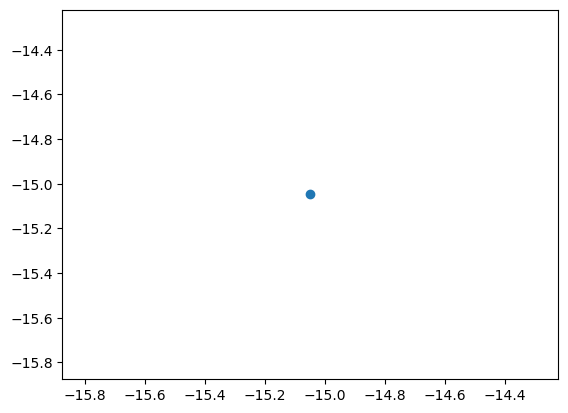

t =  0.00s   x =   -15.05 m    y =   -15.05 m    vx =    49.40 m/s    vy =    49.40 m/s


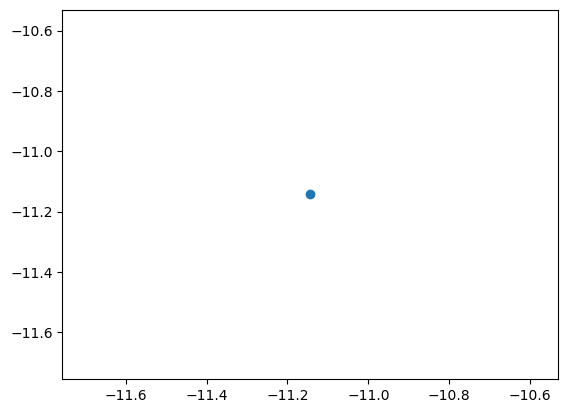

t =  0.08s   x =   -11.14 m    y =   -11.14 m    vx =    48.81 m/s    vy =    48.81 m/s


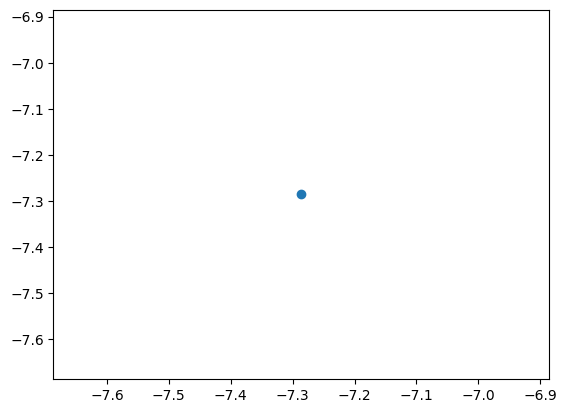

t =  0.16s   x =    -7.29 m    y =    -7.29 m    vx =    48.22 m/s    vy =    48.22 m/s


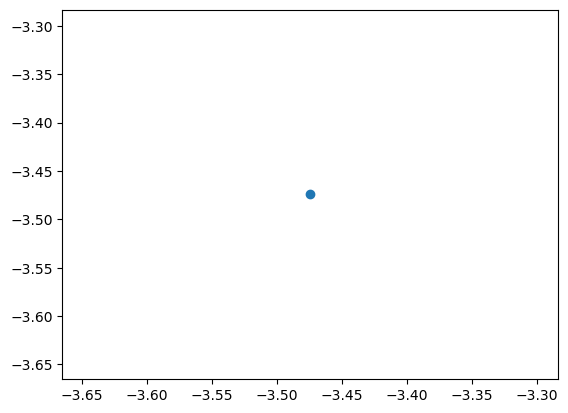

t =  0.24s   x =    -3.47 m    y =    -3.47 m    vx =    47.64 m/s    vy =    47.64 m/s


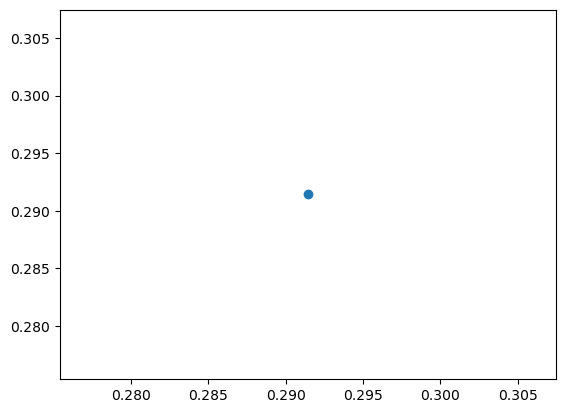

t =  0.32s   x =     0.29 m    y =     0.29 m    vx =    47.07 m/s    vy =    47.07 m/s


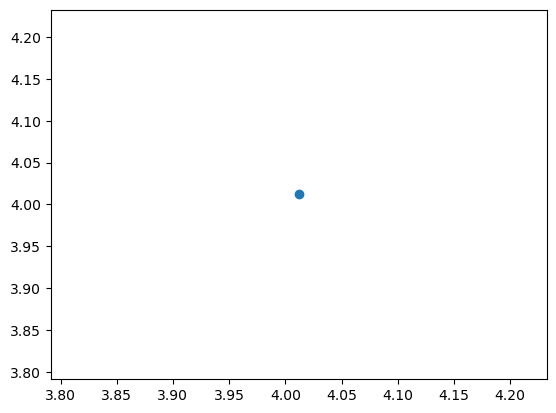

t =  0.40s   x =     4.01 m    y =     4.01 m    vx =    46.51 m/s    vy =    46.51 m/s


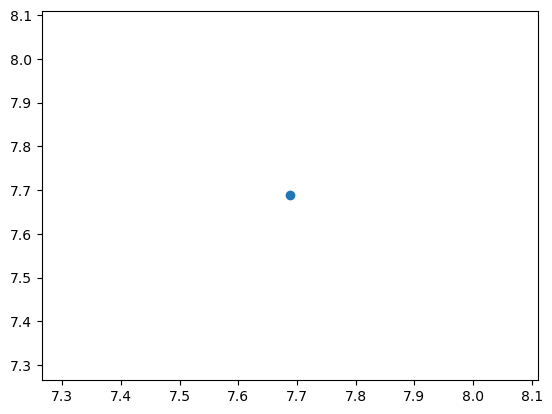

t =  0.48s   x =     7.69 m    y =     7.69 m    vx =    45.95 m/s    vy =    45.95 m/s


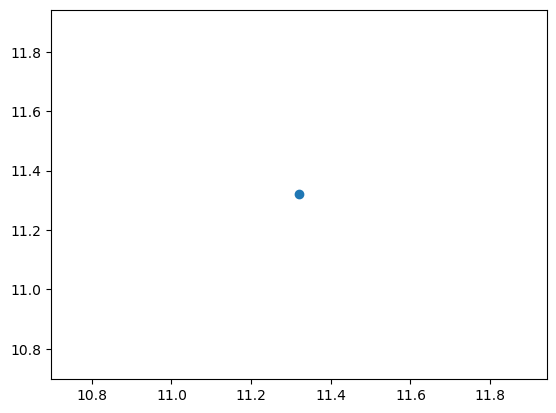

t =  0.56s   x =    11.32 m    y =    11.32 m    vx =    45.40 m/s    vy =    45.40 m/s


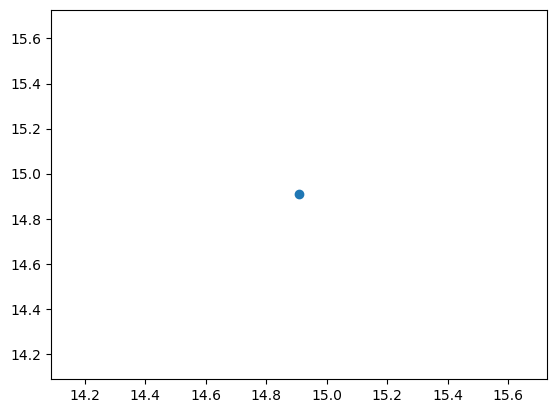

t =  0.64s   x =    14.91 m    y =    14.91 m    vx =    44.85 m/s    vy =    44.85 m/s


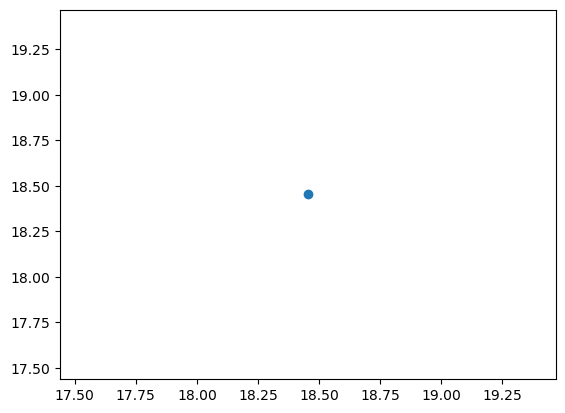

t =  0.72s   x =    18.45 m    y =    18.45 m    vx =   -44.31 m/s    vy =   -44.31 m/s


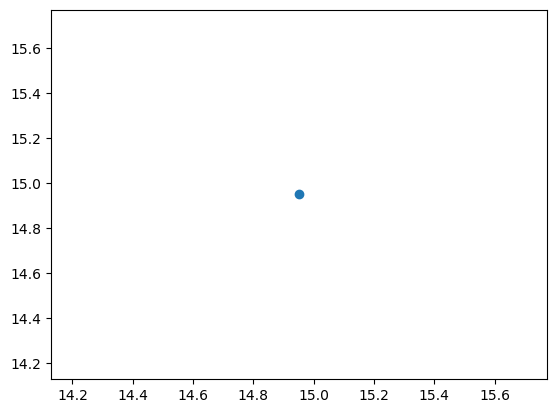

t =  0.80s   x =    14.95 m    y =    14.95 m    vx =   -43.78 m/s    vy =   -43.78 m/s


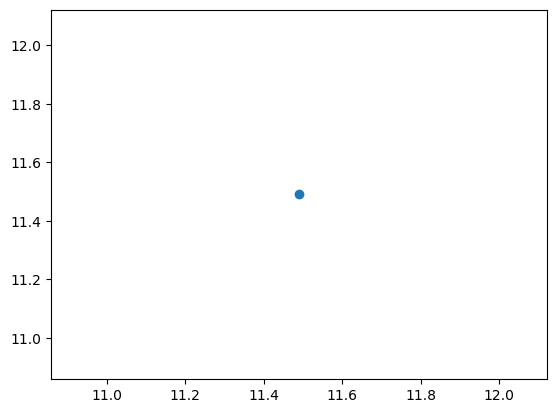

t =  0.88s   x =    11.49 m    y =    11.49 m    vx =   -43.26 m/s    vy =   -43.26 m/s


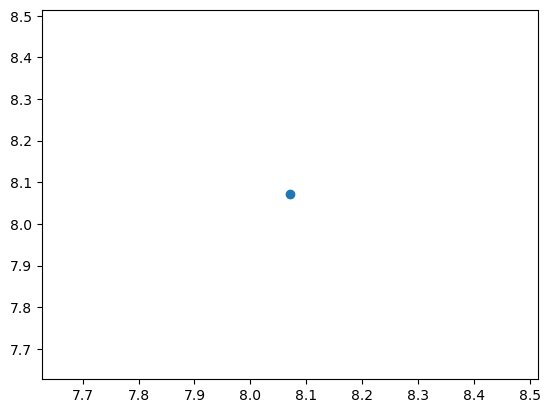

t =  0.96s   x =     8.07 m    y =     8.07 m    vx =   -42.74 m/s    vy =   -42.74 m/s


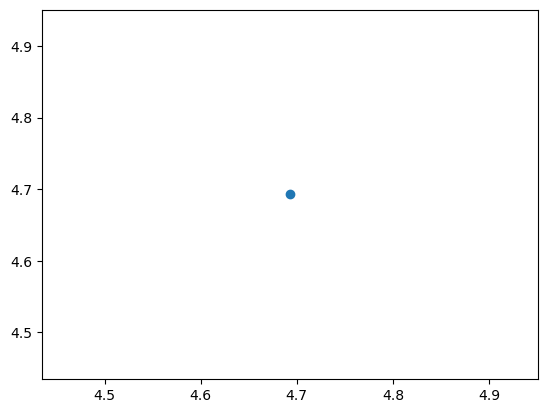

t =  1.04s   x =     4.69 m    y =     4.69 m    vx =   -42.22 m/s    vy =   -42.22 m/s


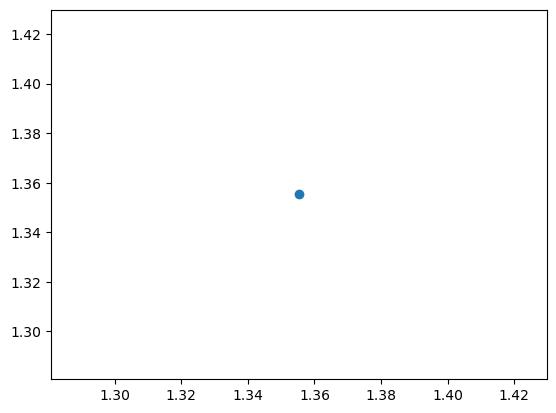

t =  1.12s   x =     1.36 m    y =     1.36 m    vx =   -41.72 m/s    vy =   -41.72 m/s


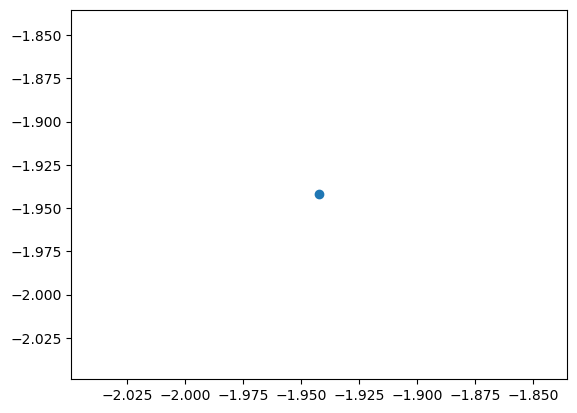

t =  1.20s   x =    -1.94 m    y =    -1.94 m    vx =   -41.22 m/s    vy =   -41.22 m/s


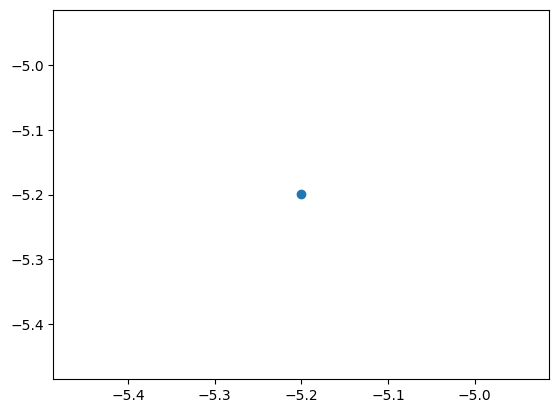

t =  1.28s   x =    -5.20 m    y =    -5.20 m    vx =   -40.72 m/s    vy =   -40.72 m/s


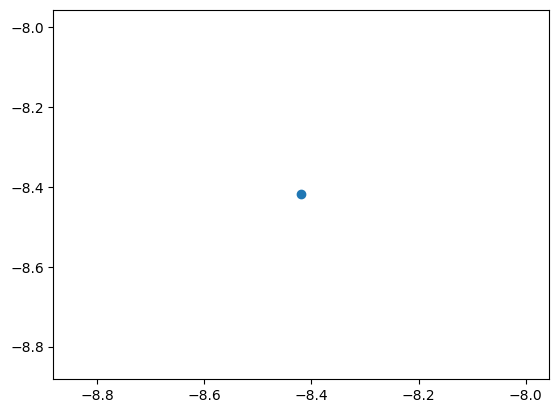

t =  1.36s   x =    -8.42 m    y =    -8.42 m    vx =   -40.23 m/s    vy =   -40.23 m/s


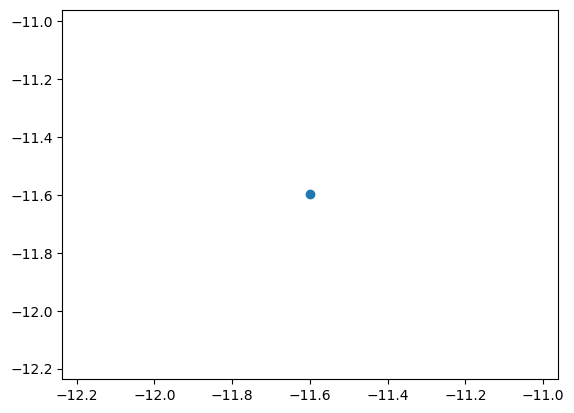

t =  1.44s   x =   -11.60 m    y =   -11.60 m    vx =   -39.75 m/s    vy =   -39.75 m/s


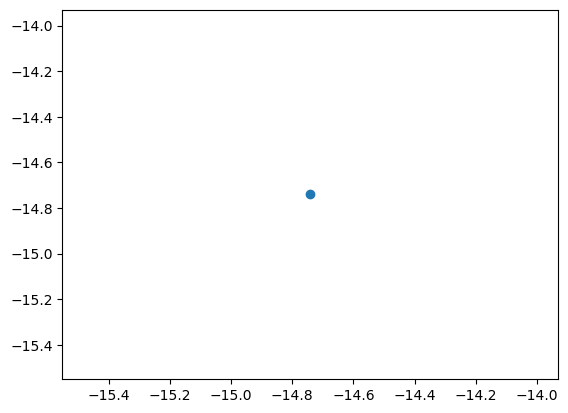

t =  1.52s   x =   -14.74 m    y =   -14.74 m    vx =   -39.27 m/s    vy =   -39.27 m/s


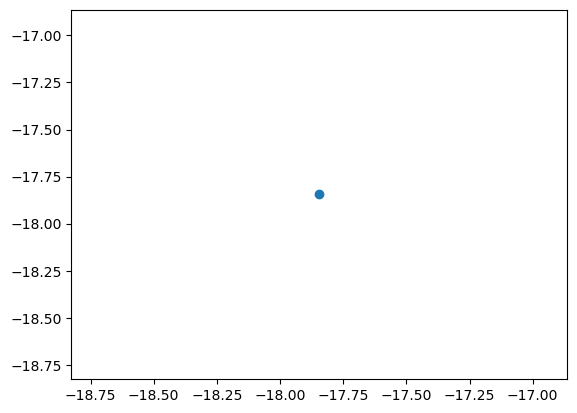

t =  1.60s   x =   -17.84 m    y =   -17.84 m    vx =    38.80 m/s    vy =    38.80 m/s


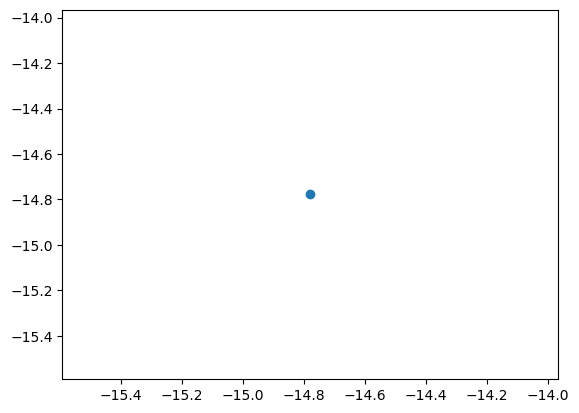

t =  1.68s   x =   -14.78 m    y =   -14.78 m    vx =    38.34 m/s    vy =    38.34 m/s


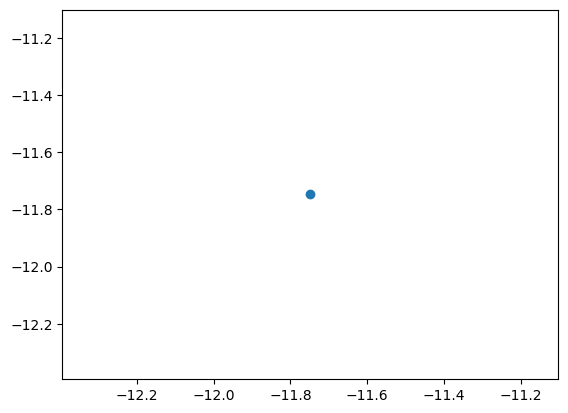

t =  1.76s   x =   -11.75 m    y =   -11.75 m    vx =    37.88 m/s    vy =    37.88 m/s


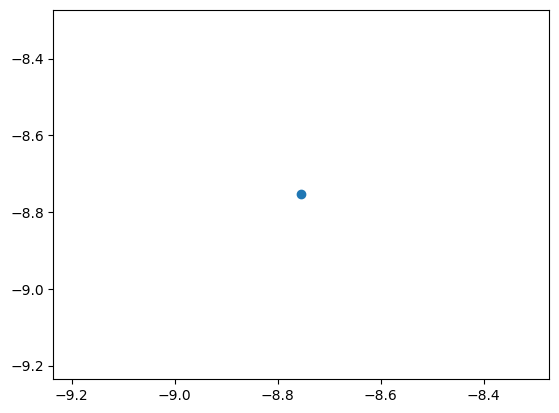

t =  1.84s   x =    -8.75 m    y =    -8.75 m    vx =    37.42 m/s    vy =    37.42 m/s


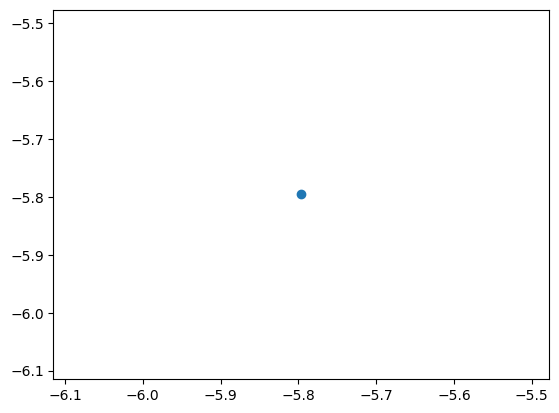

t =  1.92s   x =    -5.80 m    y =    -5.80 m    vx =    36.97 m/s    vy =    36.97 m/s


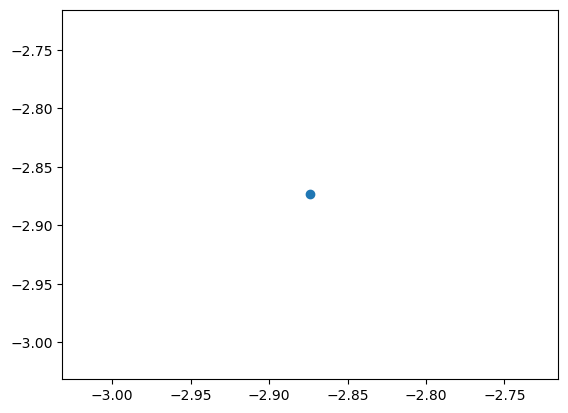

t =  2.00s   x =    -2.87 m    y =    -2.87 m    vx =    36.53 m/s    vy =    36.53 m/s


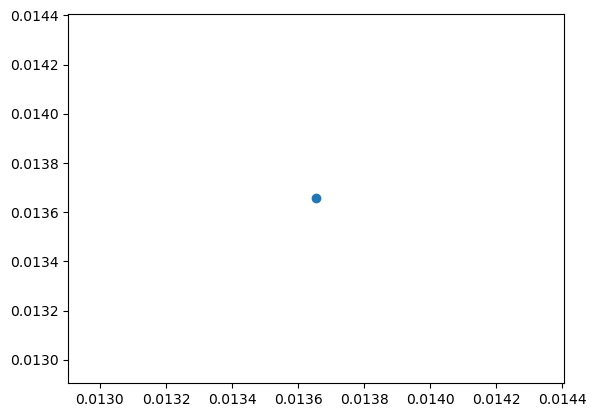

t =  2.08s   x =     0.01 m    y =     0.01 m    vx =    36.09 m/s    vy =    36.09 m/s


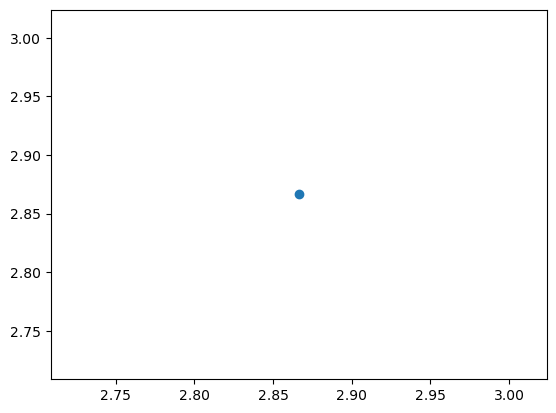

t =  2.16s   x =     2.87 m    y =     2.87 m    vx =    35.66 m/s    vy =    35.66 m/s


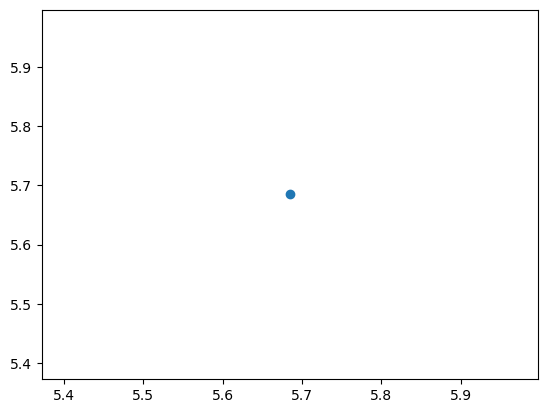

t =  2.24s   x =     5.68 m    y =     5.68 m    vx =    35.23 m/s    vy =    35.23 m/s


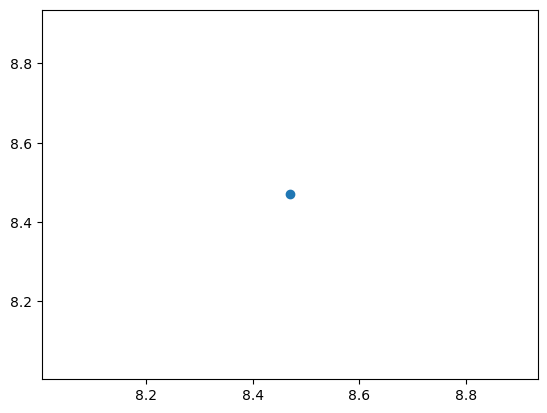

t =  2.32s   x =     8.47 m    y =     8.47 m    vx =    34.81 m/s    vy =    34.81 m/s


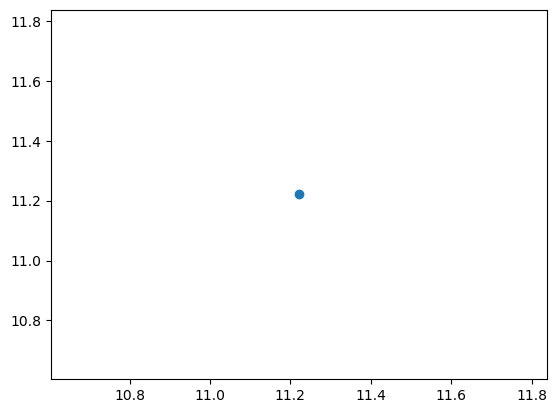

t =  2.40s   x =    11.22 m    y =    11.22 m    vx =    34.39 m/s    vy =    34.39 m/s


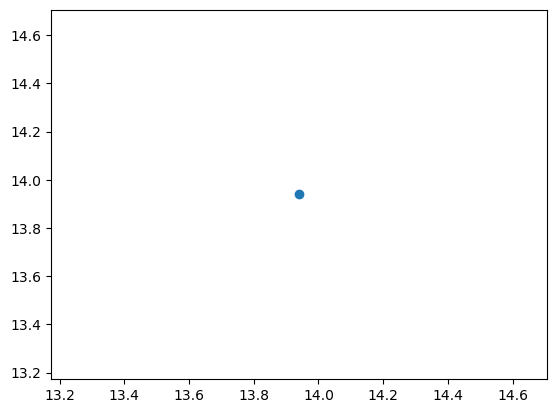

t =  2.48s   x =    13.94 m    y =    13.94 m    vx =    33.98 m/s    vy =    33.98 m/s


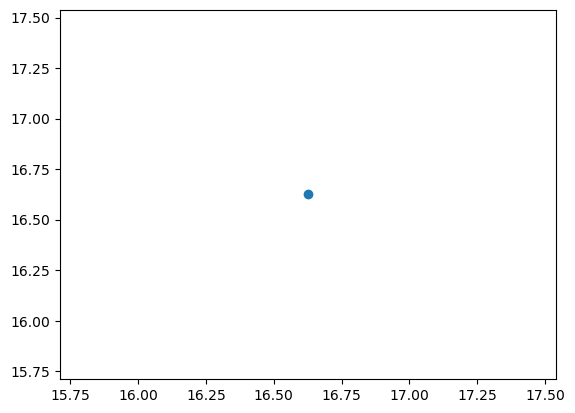

t =  2.56s   x =    16.62 m    y =    16.62 m    vx =    33.57 m/s    vy =    33.57 m/s


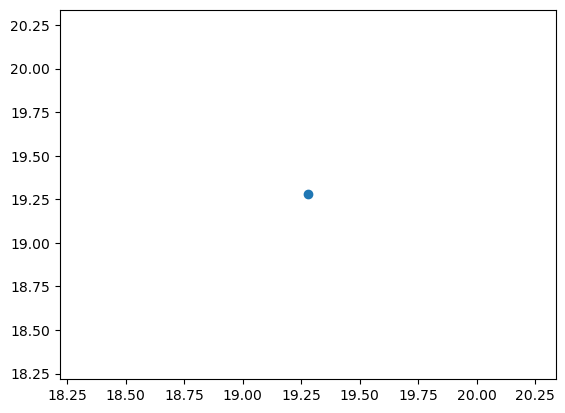

t =  2.64s   x =    19.28 m    y =    19.28 m    vx =   -33.17 m/s    vy =   -33.17 m/s


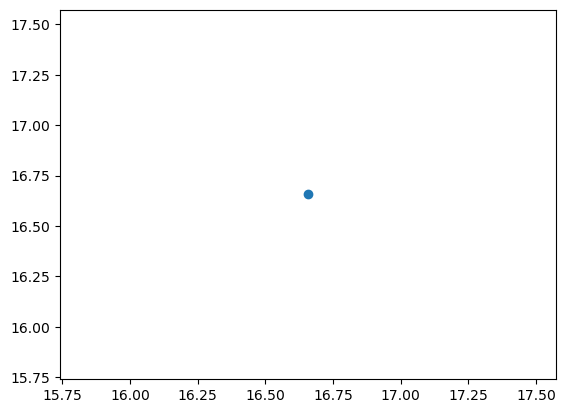

t =  2.72s   x =    16.66 m    y =    16.66 m    vx =   -32.77 m/s    vy =   -32.77 m/s


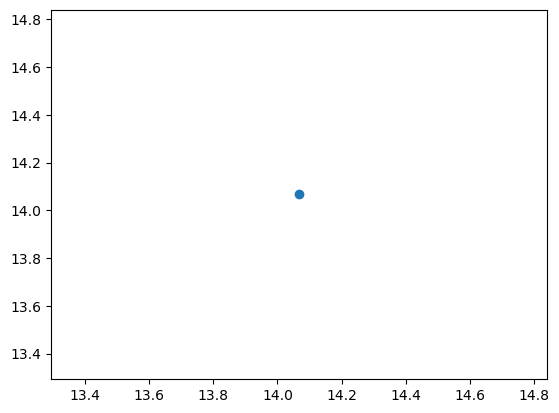

t =  2.80s   x =    14.07 m    y =    14.07 m    vx =   -32.38 m/s    vy =   -32.38 m/s


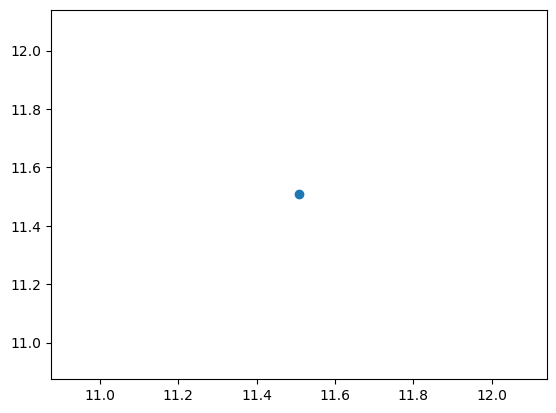

t =  2.88s   x =    11.51 m    y =    11.51 m    vx =   -31.99 m/s    vy =   -31.99 m/s


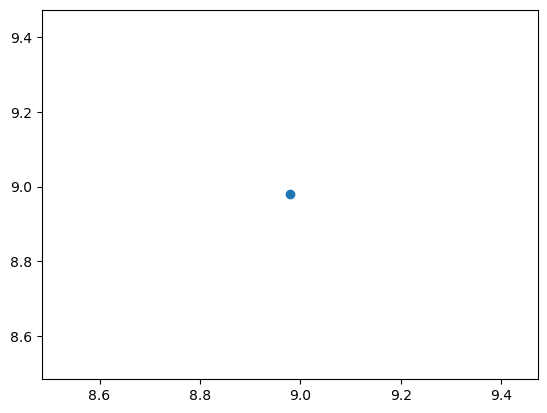

t =  2.96s   x =     8.98 m    y =     8.98 m    vx =   -31.60 m/s    vy =   -31.60 m/s


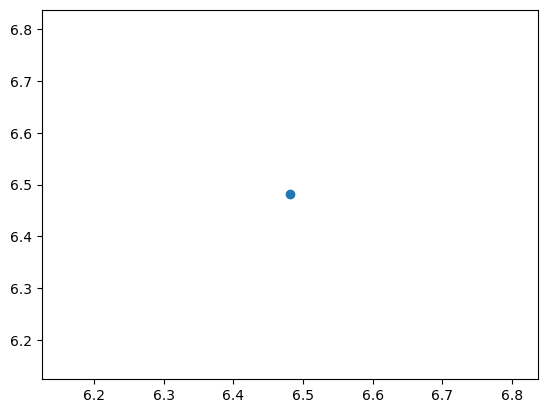

t =  3.04s   x =     6.48 m    y =     6.48 m    vx =   -31.22 m/s    vy =   -31.22 m/s


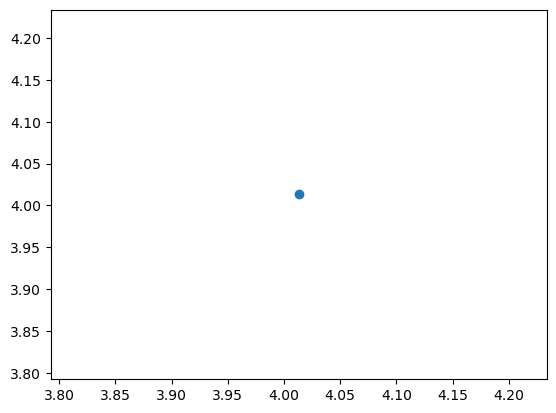

t =  3.12s   x =     4.01 m    y =     4.01 m    vx =   -30.85 m/s    vy =   -30.85 m/s


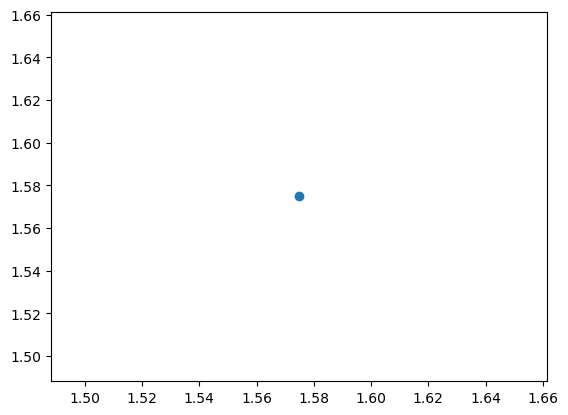

t =  3.20s   x =     1.57 m    y =     1.57 m    vx =   -30.48 m/s    vy =   -30.48 m/s


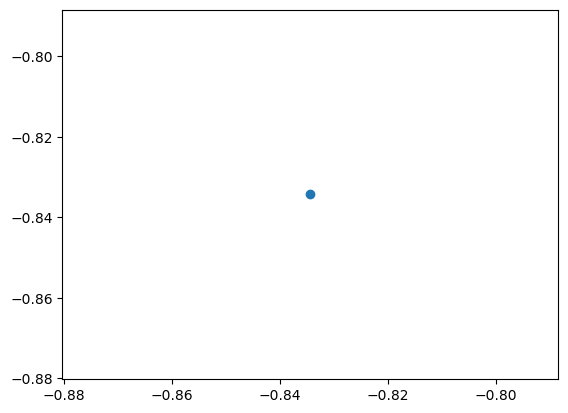

t =  3.28s   x =    -0.83 m    y =    -0.83 m    vx =   -30.11 m/s    vy =   -30.11 m/s


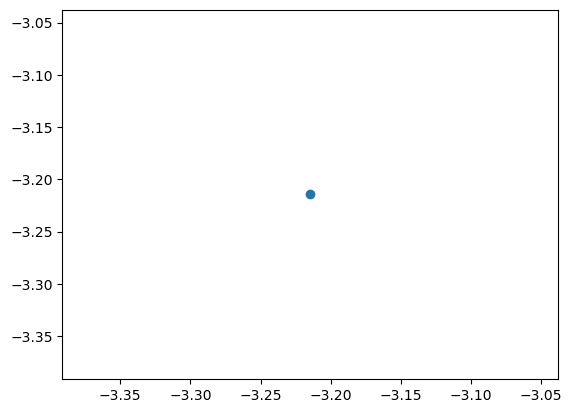

t =  3.36s   x =    -3.21 m    y =    -3.21 m    vx =   -29.75 m/s    vy =   -29.75 m/s


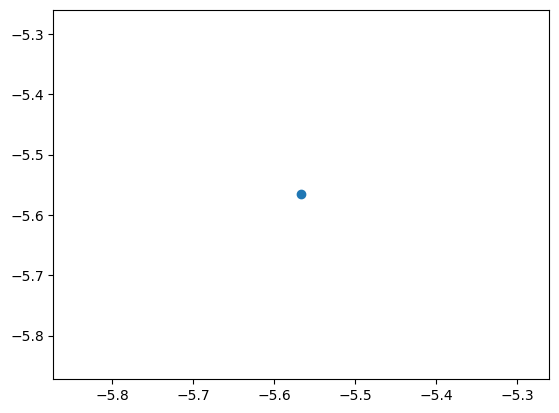

t =  3.44s   x =    -5.57 m    y =    -5.57 m    vx =   -29.40 m/s    vy =   -29.40 m/s


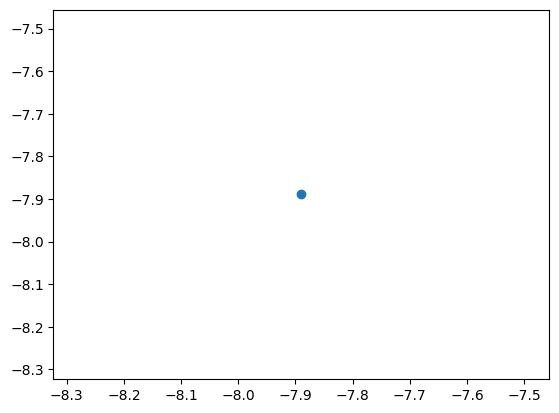

t =  3.52s   x =    -7.89 m    y =    -7.89 m    vx =   -29.04 m/s    vy =   -29.04 m/s


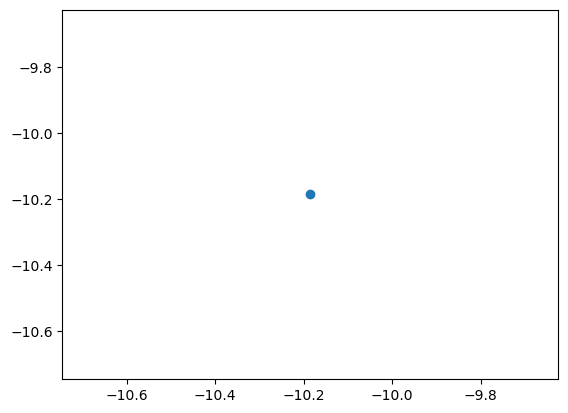

t =  3.60s   x =   -10.19 m    y =   -10.19 m    vx =   -28.69 m/s    vy =   -28.69 m/s


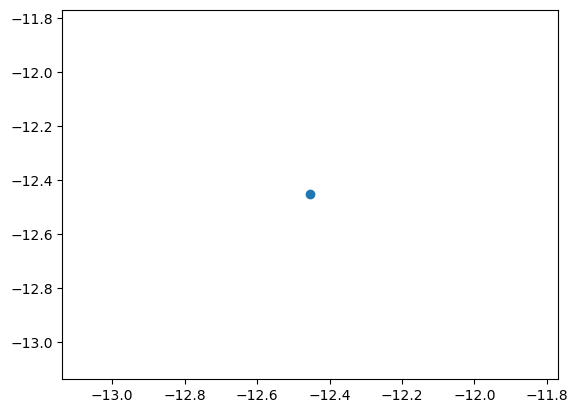

t =  3.68s   x =   -12.45 m    y =   -12.45 m    vx =   -28.35 m/s    vy =   -28.35 m/s


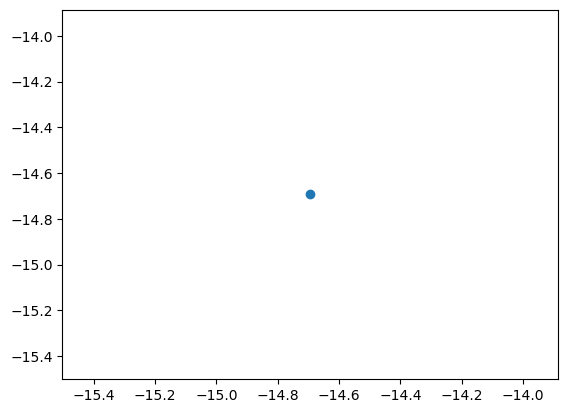

t =  3.76s   x =   -14.69 m    y =   -14.69 m    vx =   -28.01 m/s    vy =   -28.01 m/s


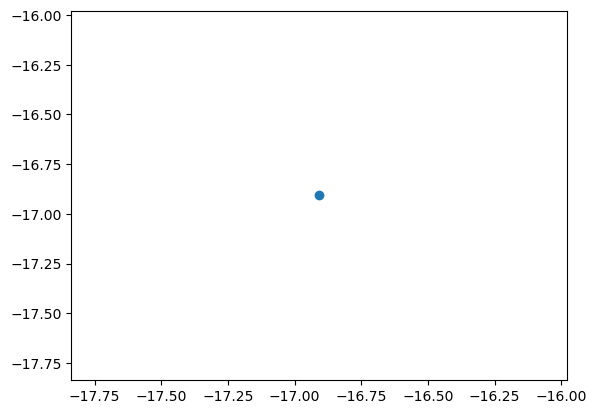

t =  3.84s   x =   -16.91 m    y =   -16.91 m    vx =   -27.67 m/s    vy =   -27.67 m/s


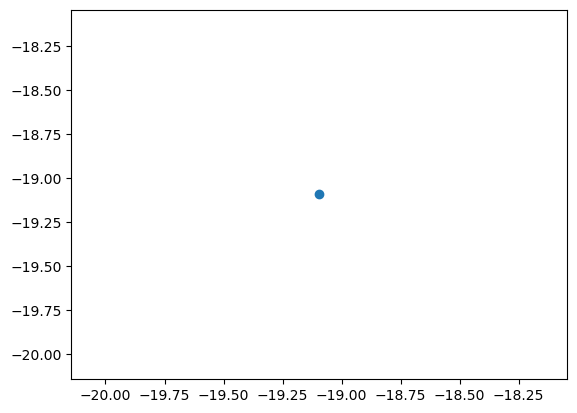

t =  3.92s   x =   -19.09 m    y =   -19.09 m    vx =    27.34 m/s    vy =    27.34 m/s


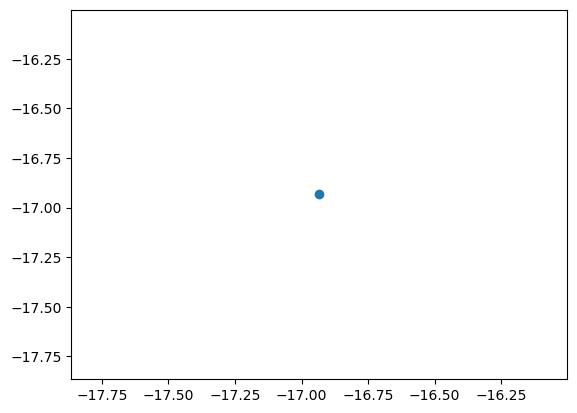

t =  4.00s   x =   -16.93 m    y =   -16.93 m    vx =    27.01 m/s    vy =    27.01 m/s


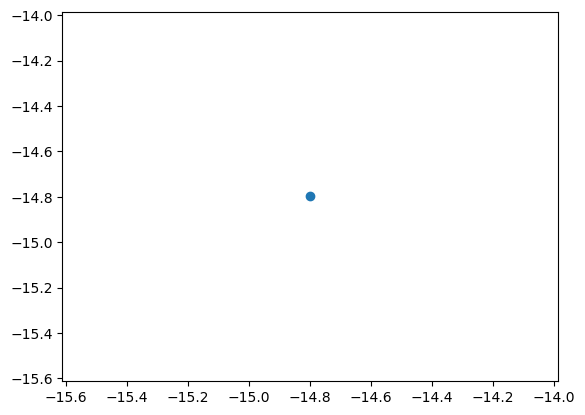

t =  4.08s   x =   -14.80 m    y =   -14.80 m    vx =    26.69 m/s    vy =    26.69 m/s


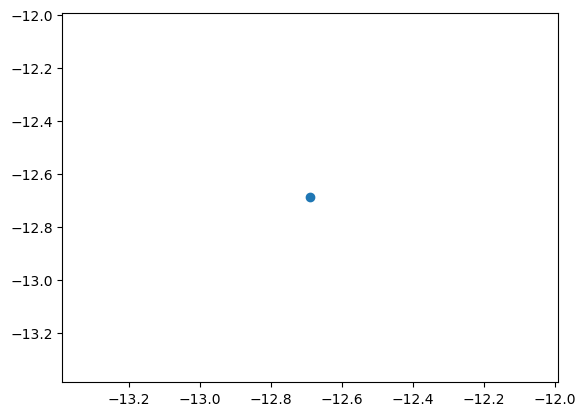

t =  4.16s   x =   -12.69 m    y =   -12.69 m    vx =    26.37 m/s    vy =    26.37 m/s


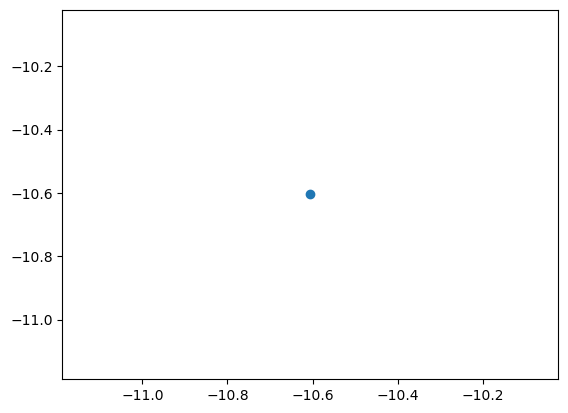

t =  4.24s   x =   -10.61 m    y =   -10.61 m    vx =    26.05 m/s    vy =    26.05 m/s


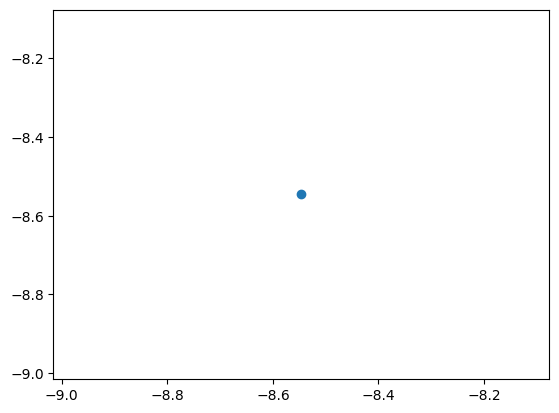

t =  4.32s   x =    -8.55 m    y =    -8.55 m    vx =    25.74 m/s    vy =    25.74 m/s


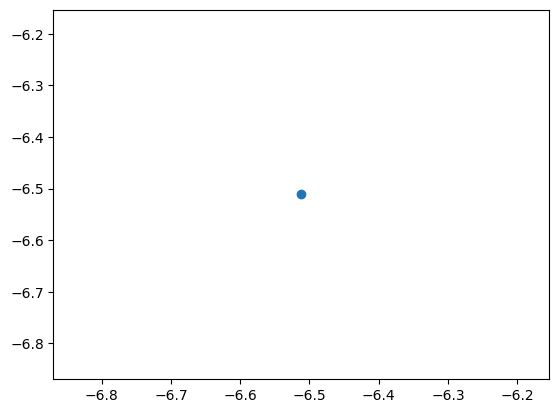

t =  4.40s   x =    -6.51 m    y =    -6.51 m    vx =    25.43 m/s    vy =    25.43 m/s


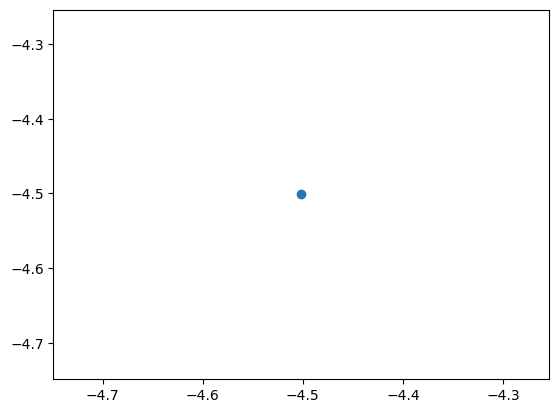

t =  4.48s   x =    -4.50 m    y =    -4.50 m    vx =    25.13 m/s    vy =    25.13 m/s


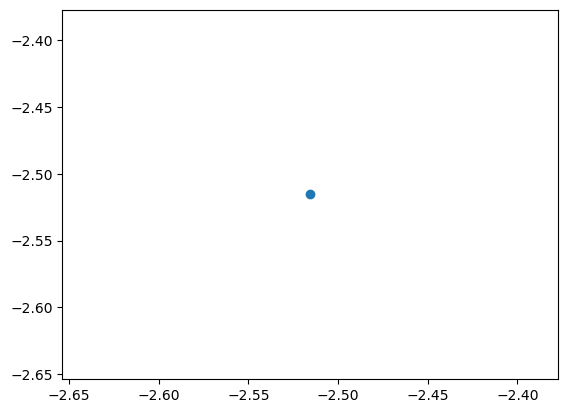

t =  4.56s   x =    -2.52 m    y =    -2.52 m    vx =    24.82 m/s    vy =    24.82 m/s


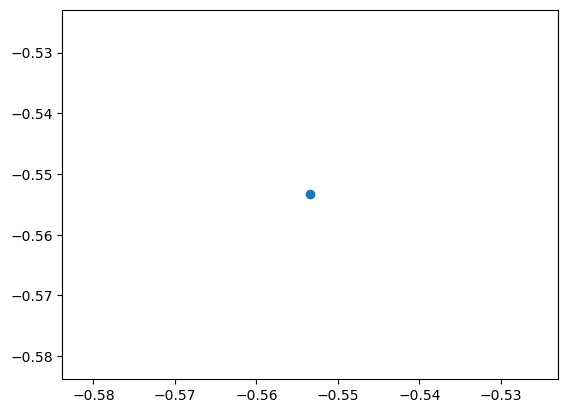

t =  4.64s   x =    -0.55 m    y =    -0.55 m    vx =    24.53 m/s    vy =    24.53 m/s


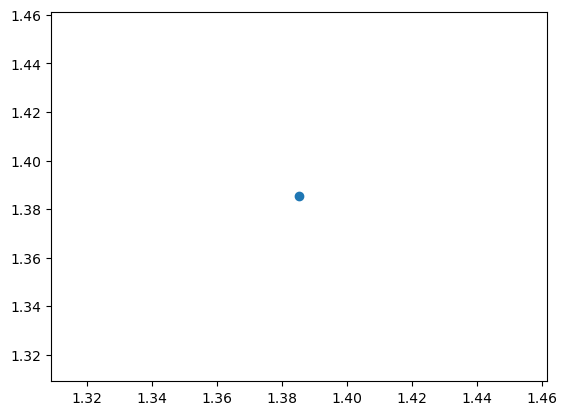

t =  4.72s   x =     1.39 m    y =     1.39 m    vx =    24.23 m/s    vy =    24.23 m/s


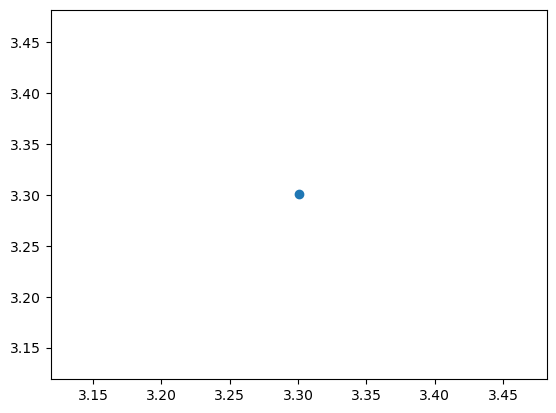

t =  4.80s   x =     3.30 m    y =     3.30 m    vx =    23.94 m/s    vy =    23.94 m/s


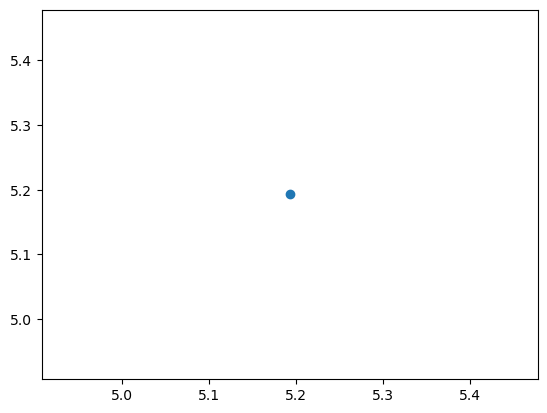

t =  4.88s   x =     5.19 m    y =     5.19 m    vx =    23.65 m/s    vy =    23.65 m/s


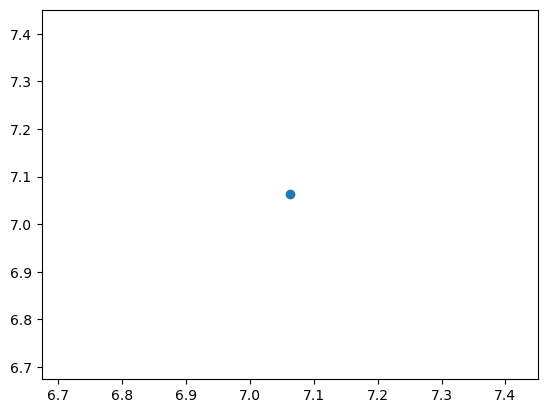

t =  4.96s   x =     7.06 m    y =     7.06 m    vx =    23.37 m/s    vy =    23.37 m/s


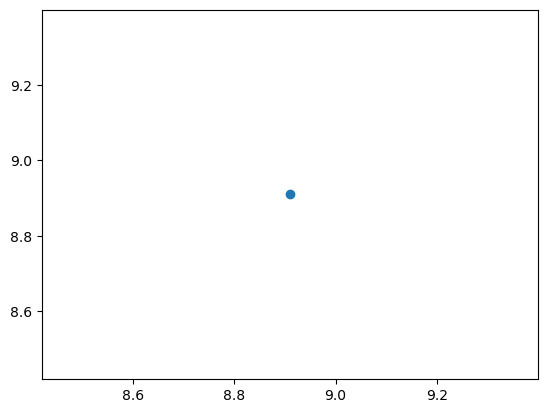

t =  5.04s   x =     8.91 m    y =     8.91 m    vx =    23.09 m/s    vy =    23.09 m/s


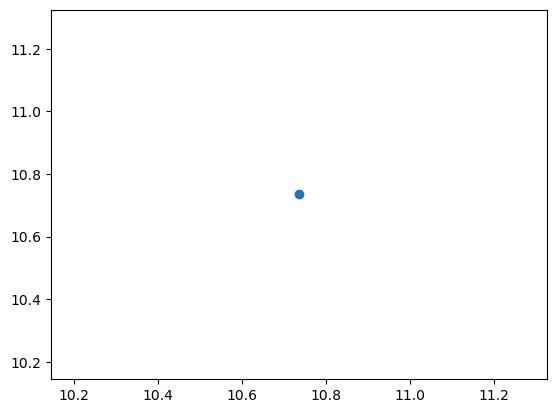

t =  5.12s   x =    10.73 m    y =    10.73 m    vx =    22.81 m/s    vy =    22.81 m/s


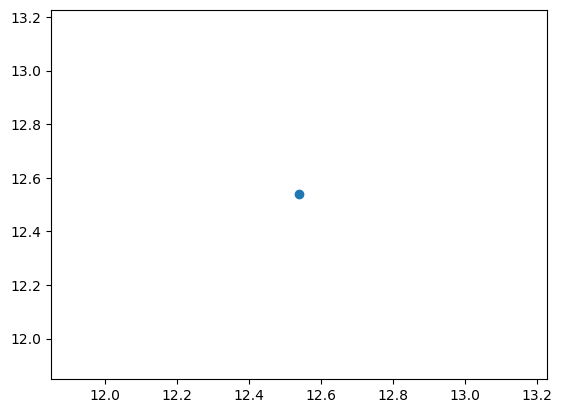

t =  5.20s   x =    12.54 m    y =    12.54 m    vx =    22.54 m/s    vy =    22.54 m/s


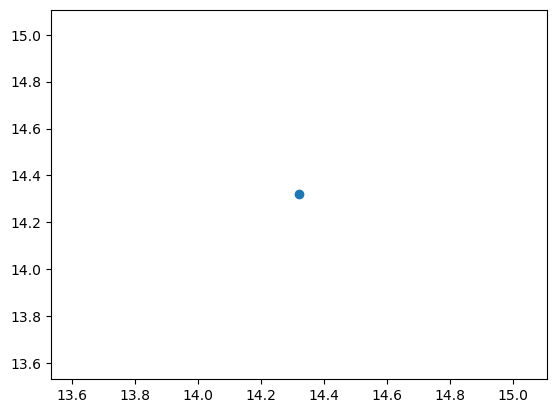

t =  5.28s   x =    14.32 m    y =    14.32 m    vx =    22.27 m/s    vy =    22.27 m/s


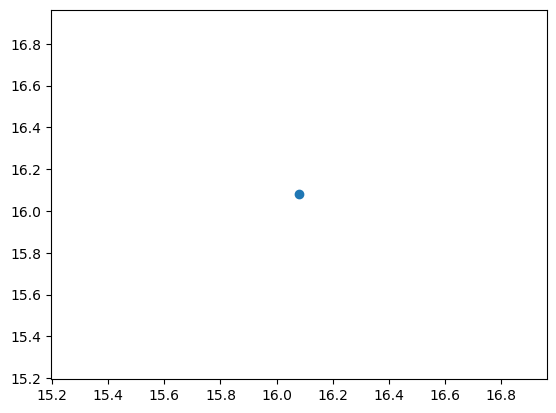

t =  5.36s   x =    16.08 m    y =    16.08 m    vx =    22.00 m/s    vy =    22.00 m/s


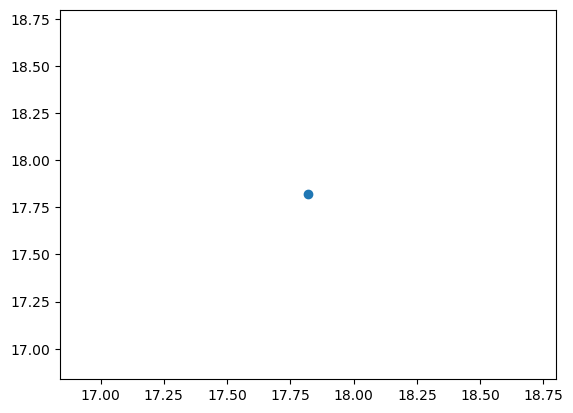

t =  5.44s   x =    17.82 m    y =    17.82 m    vx =    21.74 m/s    vy =    21.74 m/s


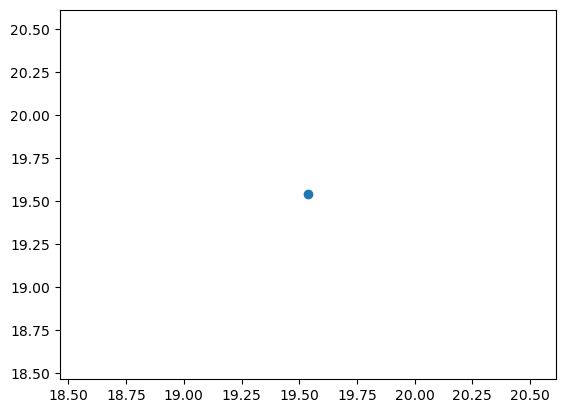

t =  5.52s   x =    19.54 m    y =    19.54 m    vx =   -21.48 m/s    vy =   -21.48 m/s


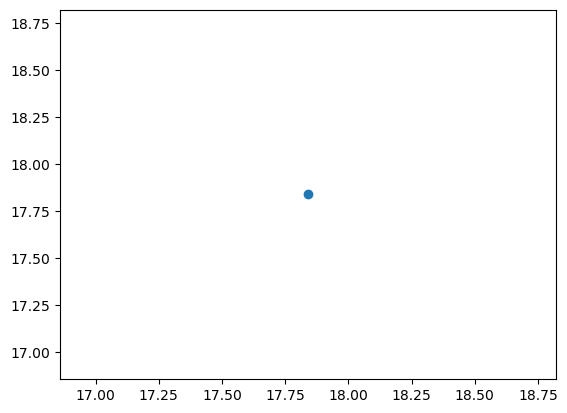

t =  5.60s   x =    17.84 m    y =    17.84 m    vx =   -21.22 m/s    vy =   -21.22 m/s


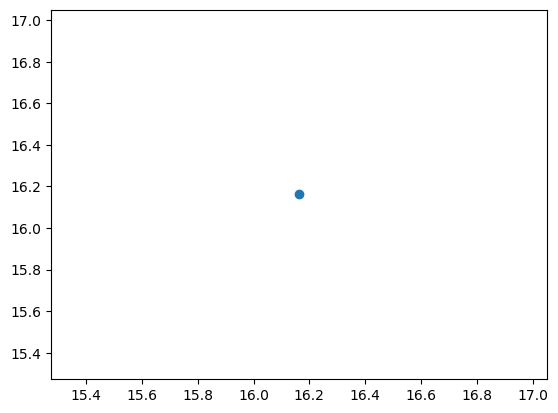

t =  5.68s   x =    16.16 m    y =    16.16 m    vx =   -20.96 m/s    vy =   -20.96 m/s


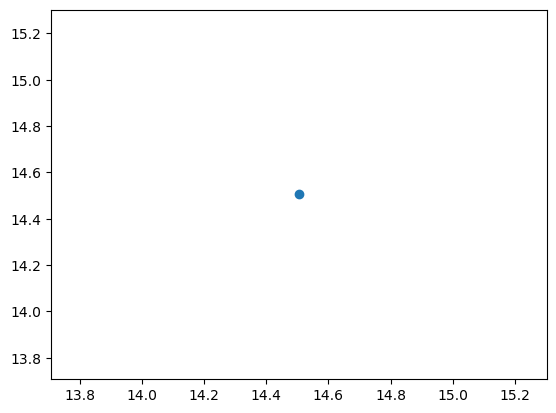

t =  5.76s   x =    14.50 m    y =    14.50 m    vx =   -20.71 m/s    vy =   -20.71 m/s


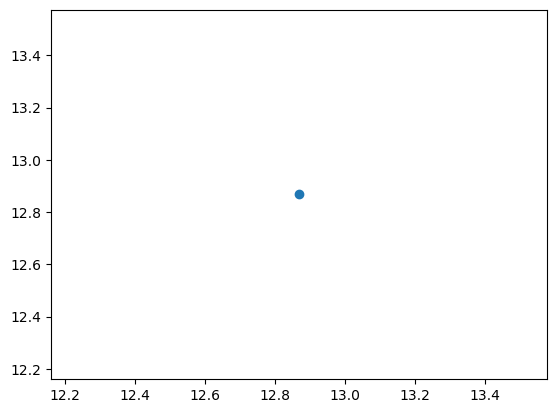

t =  5.84s   x =    12.87 m    y =    12.87 m    vx =   -20.46 m/s    vy =   -20.46 m/s


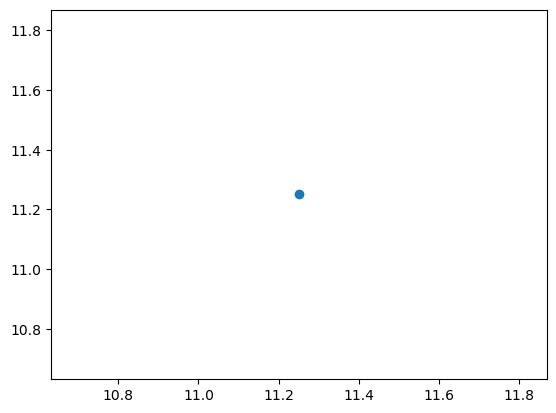

t =  5.92s   x =    11.25 m    y =    11.25 m    vx =   -20.22 m/s    vy =   -20.22 m/s


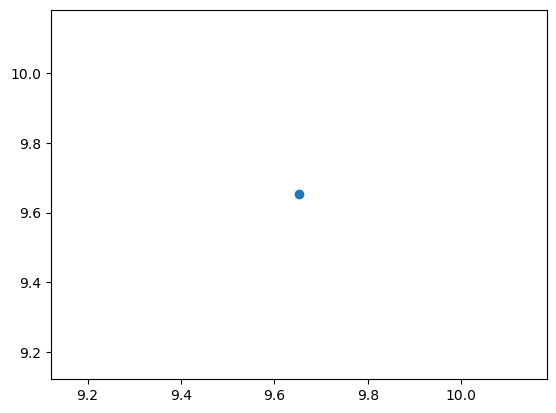

t =  6.00s   x =     9.65 m    y =     9.65 m    vx =   -19.98 m/s    vy =   -19.98 m/s


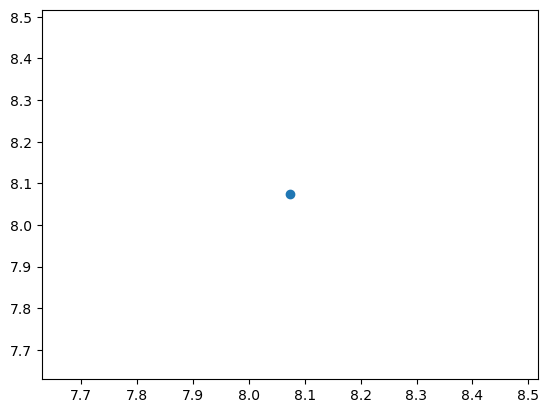

t =  6.08s   x =     8.07 m    y =     8.07 m    vx =   -19.74 m/s    vy =   -19.74 m/s


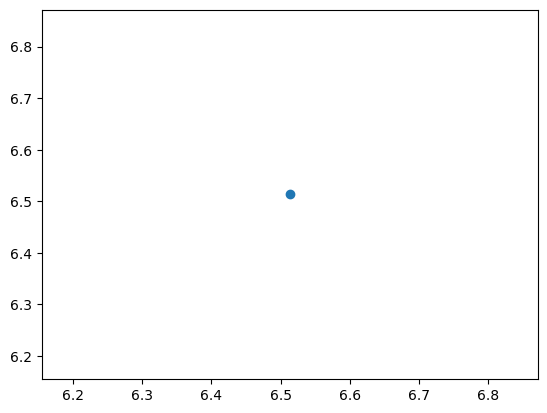

t =  6.16s   x =     6.51 m    y =     6.51 m    vx =   -19.50 m/s    vy =   -19.50 m/s


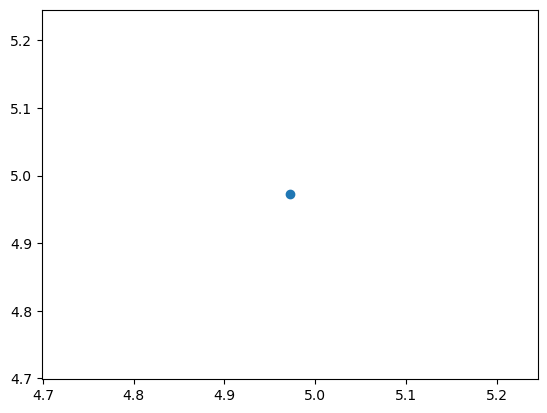

t =  6.24s   x =     4.97 m    y =     4.97 m    vx =   -19.26 m/s    vy =   -19.26 m/s


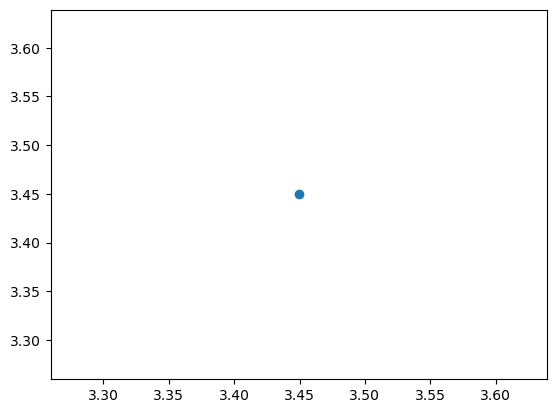

t =  6.32s   x =     3.45 m    y =     3.45 m    vx =   -19.03 m/s    vy =   -19.03 m/s


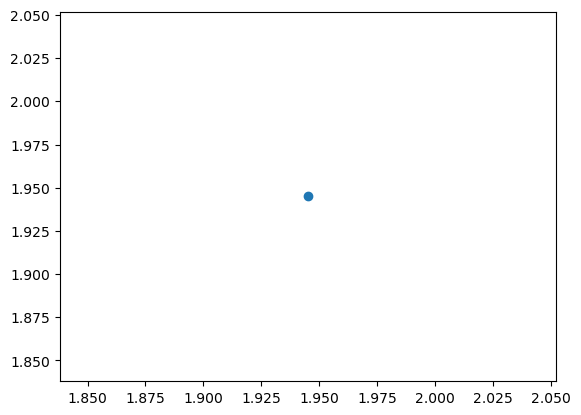

t =  6.40s   x =     1.94 m    y =     1.94 m    vx =   -18.81 m/s    vy =   -18.81 m/s


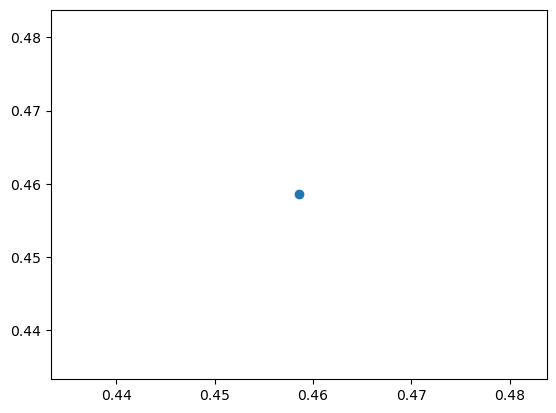

t =  6.48s   x =     0.46 m    y =     0.46 m    vx =   -18.58 m/s    vy =   -18.58 m/s


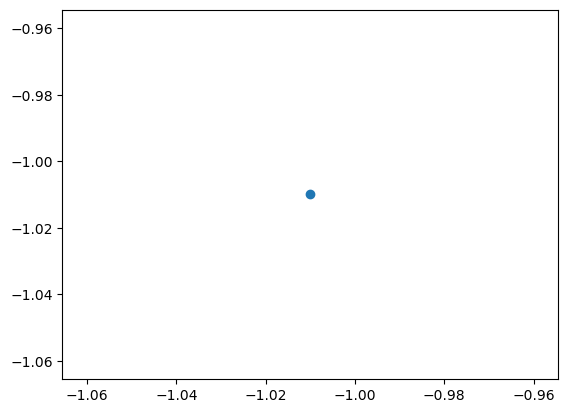

t =  6.56s   x =    -1.01 m    y =    -1.01 m    vx =   -18.36 m/s    vy =   -18.36 m/s


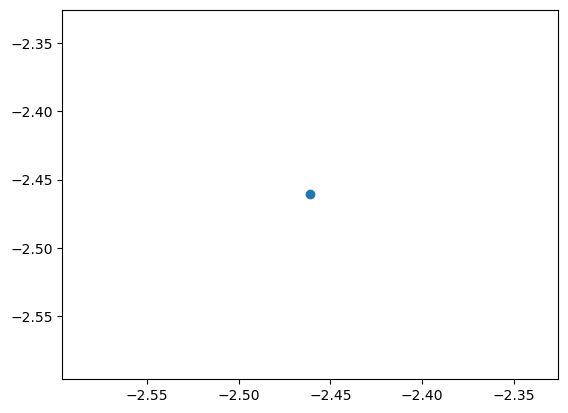

t =  6.64s   x =    -2.46 m    y =    -2.46 m    vx =   -18.14 m/s    vy =   -18.14 m/s


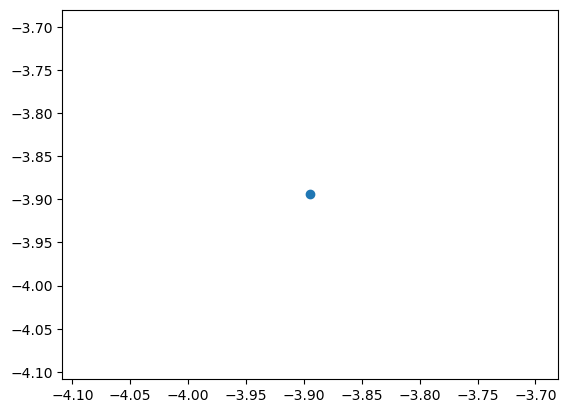

t =  6.72s   x =    -3.89 m    y =    -3.89 m    vx =   -17.92 m/s    vy =   -17.92 m/s


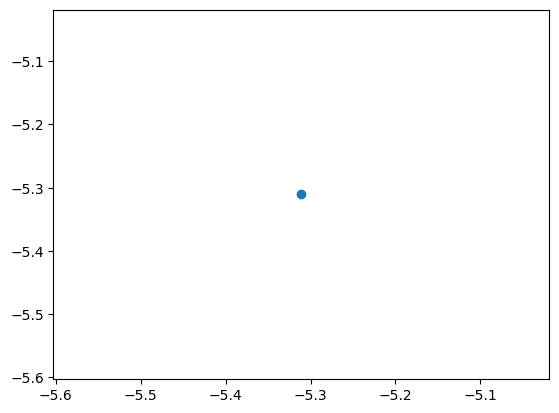

t =  6.80s   x =    -5.31 m    y =    -5.31 m    vx =   -17.70 m/s    vy =   -17.70 m/s


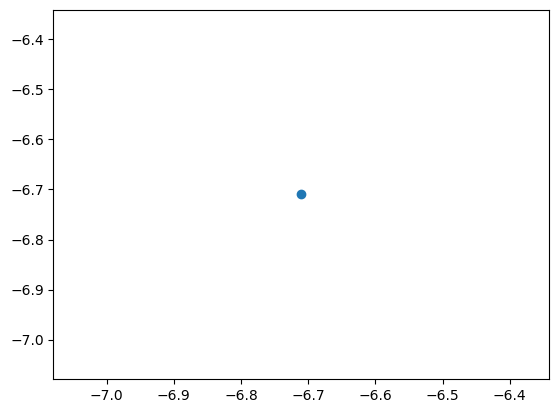

t =  6.88s   x =    -6.71 m    y =    -6.71 m    vx =   -17.49 m/s    vy =   -17.49 m/s


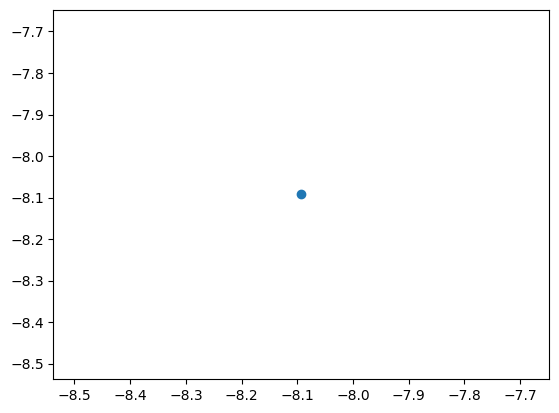

t =  6.96s   x =    -8.09 m    y =    -8.09 m    vx =   -17.28 m/s    vy =   -17.28 m/s


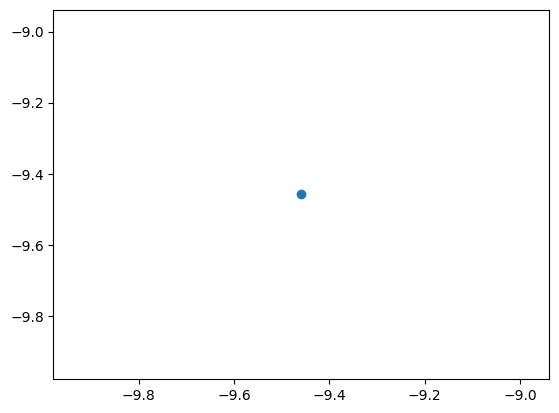

t =  7.04s   x =    -9.46 m    y =    -9.46 m    vx =   -17.07 m/s    vy =   -17.07 m/s


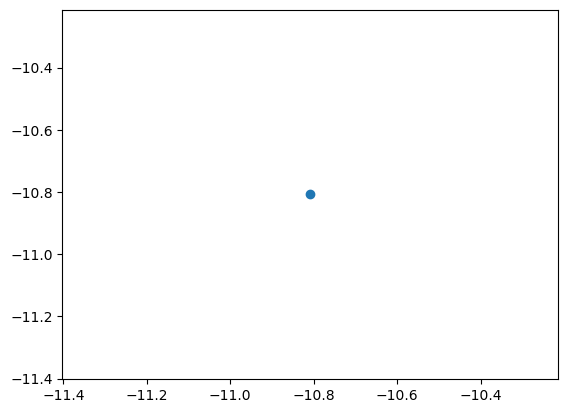

t =  7.12s   x =   -10.81 m    y =   -10.81 m    vx =   -16.87 m/s    vy =   -16.87 m/s


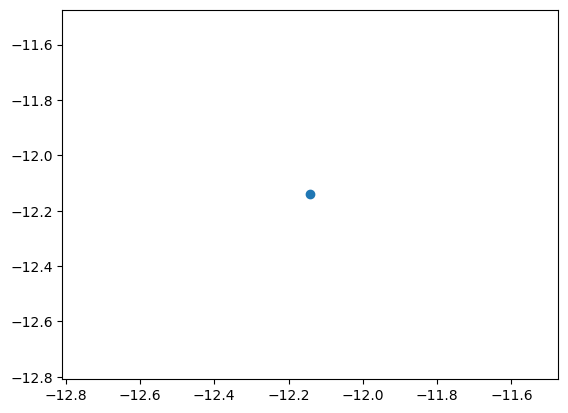

t =  7.20s   x =   -12.14 m    y =   -12.14 m    vx =   -16.67 m/s    vy =   -16.67 m/s


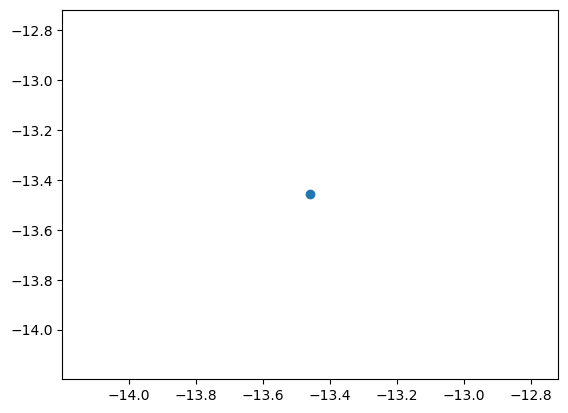

t =  7.28s   x =   -13.46 m    y =   -13.46 m    vx =   -16.47 m/s    vy =   -16.47 m/s


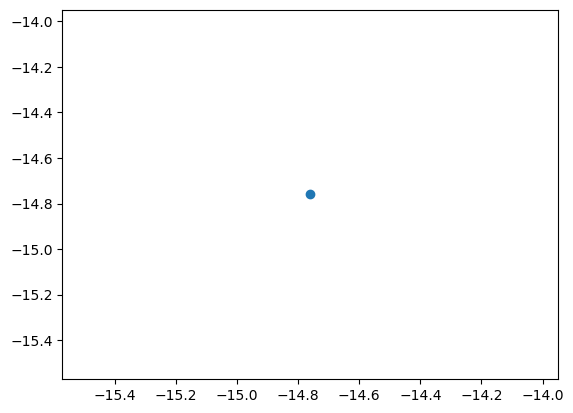

t =  7.36s   x =   -14.76 m    y =   -14.76 m    vx =   -16.27 m/s    vy =   -16.27 m/s


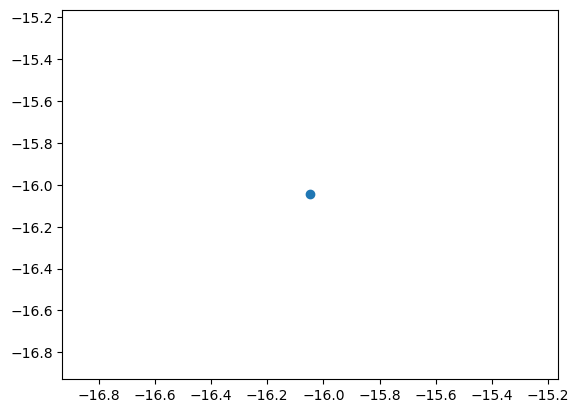

t =  7.44s   x =   -16.05 m    y =   -16.05 m    vx =   -16.07 m/s    vy =   -16.07 m/s


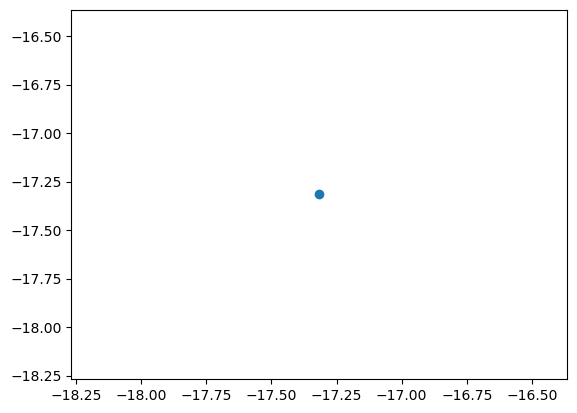

t =  7.52s   x =   -17.32 m    y =   -17.32 m    vx =   -15.88 m/s    vy =   -15.88 m/s


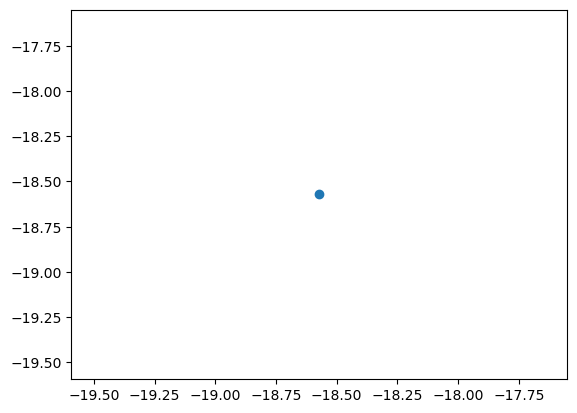

t =  7.60s   x =   -18.57 m    y =   -18.57 m    vx =   -15.69 m/s    vy =   -15.69 m/s


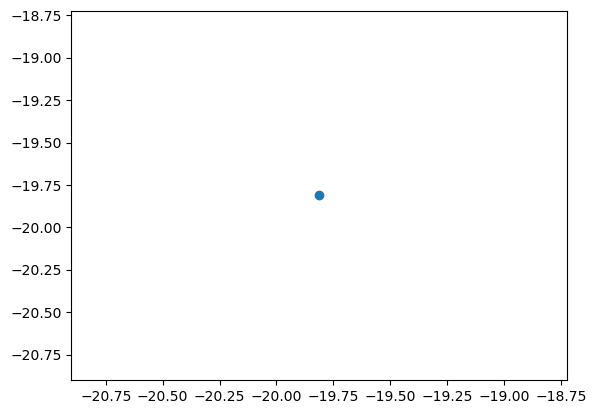

t =  7.68s   x =   -19.81 m    y =   -19.81 m    vx =    15.50 m/s    vy =    15.50 m/s


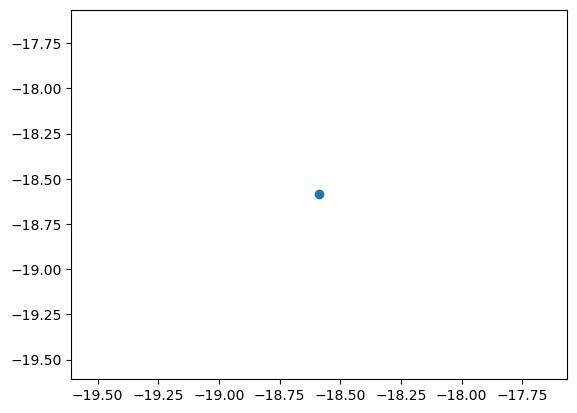

t =  7.76s   x =   -18.59 m    y =   -18.59 m    vx =    15.32 m/s    vy =    15.32 m/s


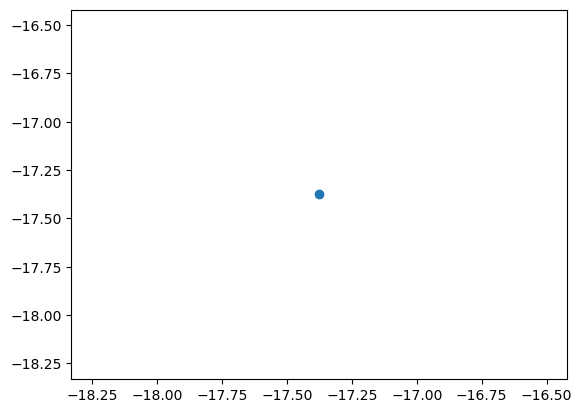

t =  7.84s   x =   -17.38 m    y =   -17.38 m    vx =    15.13 m/s    vy =    15.13 m/s


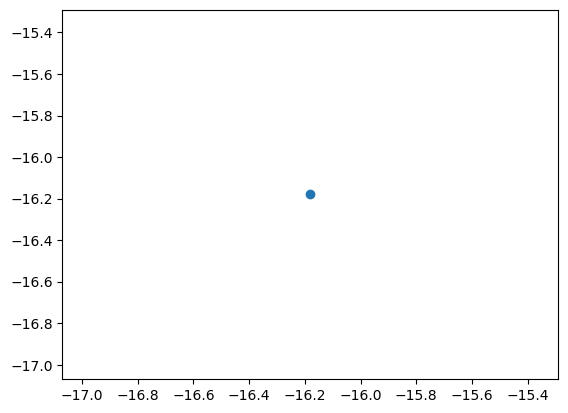

t =  7.92s   x =   -16.18 m    y =   -16.18 m    vx =    14.95 m/s    vy =    14.95 m/s


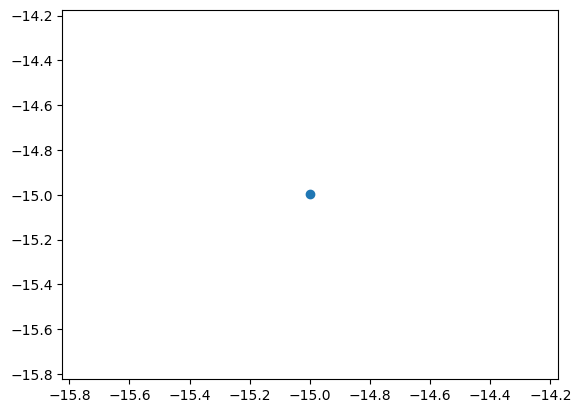

t =  8.00s   x =   -15.00 m    y =   -15.00 m    vx =    14.77 m/s    vy =    14.77 m/s


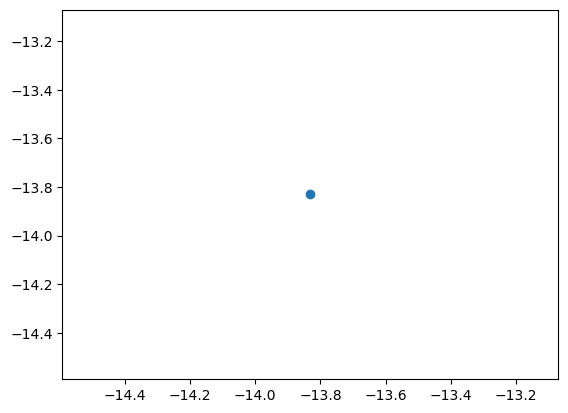

t =  8.08s   x =   -13.83 m    y =   -13.83 m    vx =    14.59 m/s    vy =    14.59 m/s


In [18]:
import time
import matplotlib.pyplot as plt

class Particle2D:
    def __init__(self, position=(0.0, 0.0), velocity=(40.0, 30.0)):
        self.x, self.y = position
        self.vx, self.vy = velocity

    def update(self, dt, drag=0.15):
        self.vx *= (1 - drag * dt)
        self.vy *= (1 - drag * dt)
        
        self.x += self.vx * dt
        self.y += self.vy * dt

    def __str__(self):
        return f"x = {self.x:8.2f} m    y = {self.y:8.2f} m    vx = {self.vx:8.2f} m/s    vy = {self.vy:8.2f} m/s"
    
p = Particle2D(position=(-19.0, -19.0), velocity=(50.0, 50.0))

t = 0.0
total_time = 8.1

while t < total_time:
    p.update(dt=0.08)
    
    if p.x+(p.vx*dt)>=20 or p.x+(p.vx*dt)<=-20:
        p.vx=-p.vx
        
    if p.y+(p.vy*dt)>=20 or p.y+(p.vy*dt)<=-20:
        p.vy=-p.vy
    
    plt.scatter(p.x, p.y)
    plt.show()
    print(f"t = {t:5.2f}s   {p}")
    time.sleep(dt)
    t += dt
